In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
df = pd.read_csv(r"C:\Users\wwwmu\Downloads\archive\global air pollution dataset.csv")

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(10)

Shape: (23463, 12)
Columns: ['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value', 'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value', 'PM2.5 AQI Category']


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good
5,United States of America,Punta Gorda,54,Moderate,1,Good,14,Good,11,Good,54,Moderate
6,Germany,Puttlingen,62,Moderate,1,Good,35,Good,3,Good,62,Moderate
7,Belgium,Puurs,64,Moderate,1,Good,29,Good,7,Good,64,Moderate
8,Russian Federation,Pyatigorsk,54,Moderate,1,Good,41,Good,1,Good,54,Moderate
9,Egypt,Qalyub,142,Unhealthy for Sensitive Groups,3,Good,89,Moderate,9,Good,142,Unhealthy for Sensitive Groups


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Country             23036 non-null  str  
 1   City                23462 non-null  str  
 2   AQI Value           23463 non-null  int64
 3   AQI Category        23463 non-null  str  
 4   CO AQI Value        23463 non-null  int64
 5   CO AQI Category     23463 non-null  str  
 6   Ozone AQI Value     23463 non-null  int64
 7   Ozone AQI Category  23463 non-null  str  
 8   NO2 AQI Value       23463 non-null  int64
 9   NO2 AQI Category    23463 non-null  str  
 10  PM2.5 AQI Value     23463 non-null  int64
 11  PM2.5 AQI Category  23463 non-null  str  
dtypes: int64(5), str(7)
memory usage: 2.1 MB


In [4]:
num_cols = ['AQI Value', 'CO AQI Value', 'Ozone AQI Value',
            'NO2 AQI Value', 'PM2.5 AQI Value']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


cat_cols = ['Country', 'City', 'AQI Category', 'CO AQI Category',
            'Ozone AQI Category', 'NO2 AQI Category', 'PM2.5 AQI Category']

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

print('Data types after fixing:')
print(df.dtypes)

Data types after fixing:
Country                 str
City                    str
AQI Value             int64
AQI Category            str
CO AQI Value          int64
CO AQI Category         str
Ozone AQI Value       int64
Ozone AQI Category      str
NO2 AQI Value         int64
NO2 AQI Category        str
PM2.5 AQI Value       int64
PM2.5 AQI Category      str
dtype: object


In [6]:
missing = df.isnull().sum()


missing_df = pd.DataFrame({'Missing Count': missing})
print(missing_df)

df = df.dropna(subset=['AQI Value'])
df = df.drop_duplicates()

print(f'\nRows after cleaning: {len(df)}')

                    Missing Count
Country                       427
City                            1
AQI Value                       0
AQI Category                    0
CO AQI Value                    0
CO AQI Category                 0
Ozone AQI Value                 0
Ozone AQI Category              0
NO2 AQI Value                   0
NO2 AQI Category                0
PM2.5 AQI Value                 0
PM2.5 AQI Category              0

Rows after cleaning: 23463


In [9]:
df[num_cols].describe()

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


In [10]:
print(f"Total unique countries : {df['Country'].nunique()}")
print(f"Total unique cities    : {df['City'].nunique()}")
print(f"\nAQI Category value counts:")
print(df['AQI Category'].value_counts())

Total unique countries : 175
Total unique cities    : 23462

AQI Category value counts:
AQI Category
Good                              9936
Moderate                          9231
Unhealthy                         2227
Unhealthy for Sensitive Groups    1591
Very Unhealthy                     287
Hazardous                          191
Name: count, dtype: int64


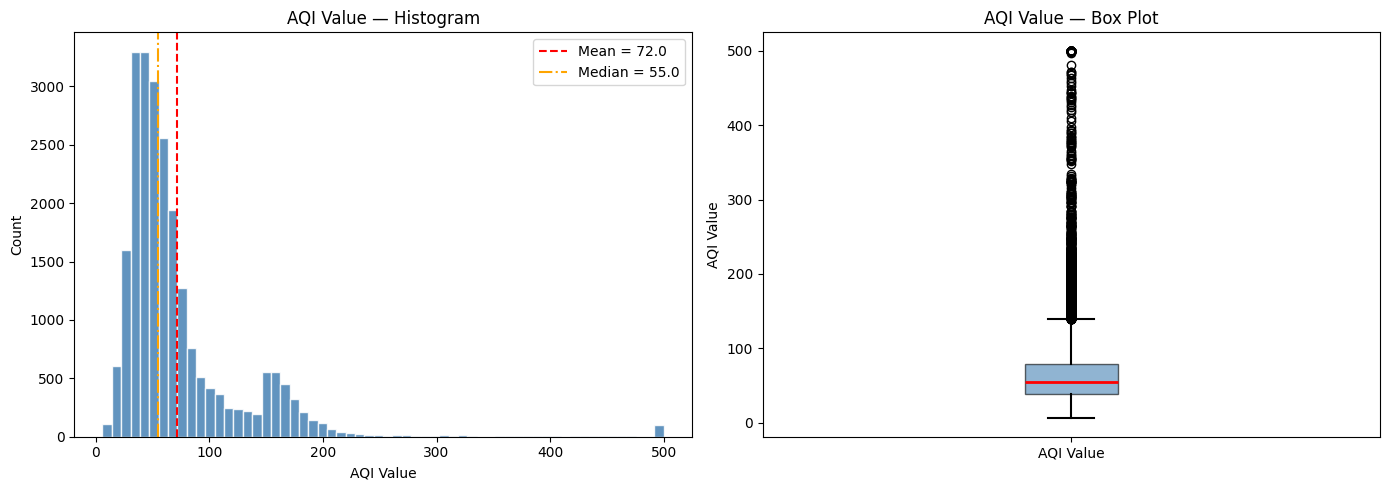

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].hist(df['AQI Value'].dropna(), bins=60,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['AQI Value'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f"Mean = {df['AQI Value'].mean():.1f}")
axes[0].axvline(df['AQI Value'].median(), color='orange', linestyle='-.', linewidth=1.5,
                label=f"Median = {df['AQI Value'].median():.1f}")
axes[0].set_title('AQI Value — Histogram')
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Count')
axes[0].legend()


axes[1].boxplot(df['AQI Value'].dropna(),
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))
axes[1].set_title('AQI Value — Box Plot')
axes[1].set_ylabel('AQI Value')
axes[1].set_xticklabels(['AQI Value'])

plt.tight_layout()
plt.show()

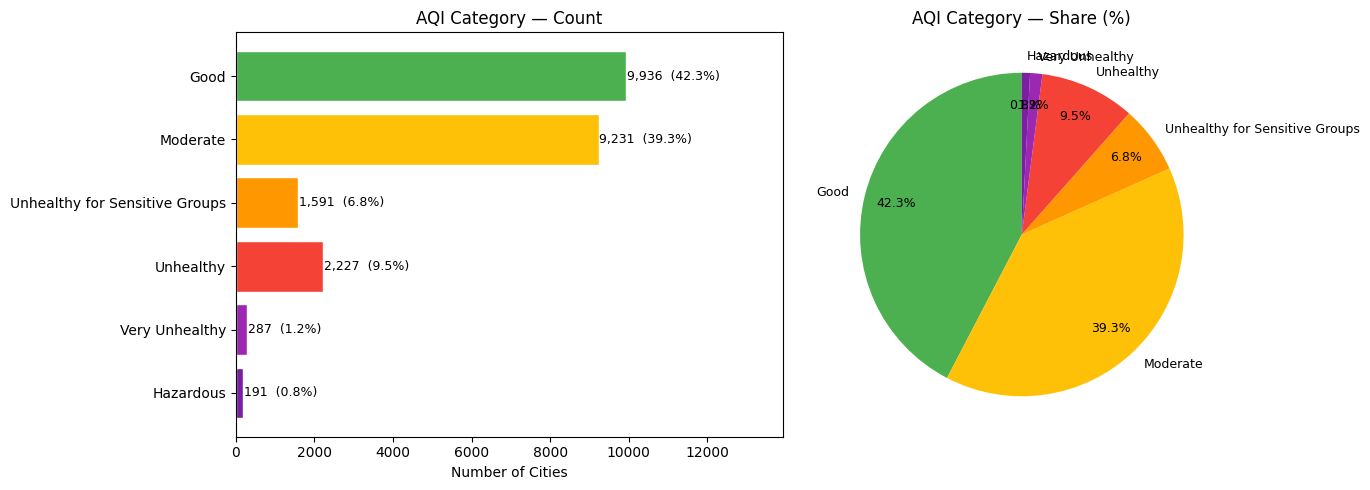

In [12]:
aqi_order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups',
             'Unhealthy', 'Very Unhealthy', 'Hazardous']
aqi_colors = ['#4CAF50', '#FFC107', '#FF9800', '#F44336', '#9C27B0', '#7B1FA2']


df_cat = df[df['AQI Category'].isin(aqi_order)].copy()
cat_counts = df_cat['AQI Category'].value_counts().reindex(aqi_order).dropna()
colors_used = [aqi_colors[aqi_order.index(c)] for c in cat_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


bars = axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1],
                    color=colors_used[::-1], edgecolor='white')
for bar, val in zip(bars, cat_counts.values[::-1]):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}  ({val/len(df_cat)*100:.1f}%)',
                 va='center', fontsize=9)
axes[0].set_xlabel('Number of Cities')
axes[0].set_title('AQI Category — Count')
axes[0].set_xlim(0, cat_counts.max() * 1.4)


axes[1].pie(cat_counts, labels=cat_counts.index,
            colors=colors_used, autopct='%1.1f%%',
            startangle=90, pctdistance=0.80,
            textprops={'fontsize': 9})
axes[1].set_title('AQI Category — Share (%)')

plt.tight_layout()
plt.show()

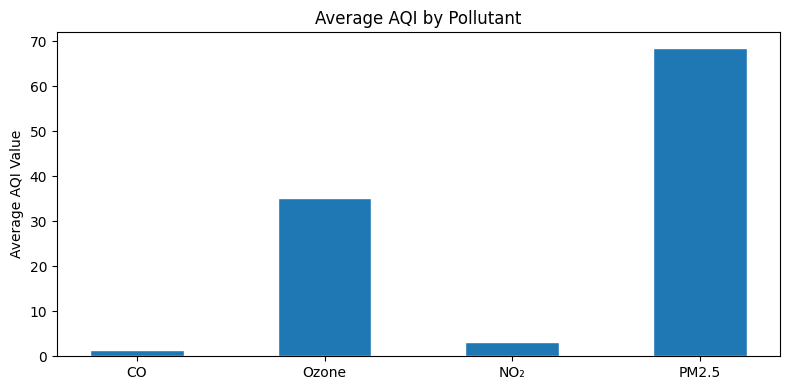

In [18]:
pollutants  = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
poll_labels = ['CO', 'Ozone', 'NO₂', 'PM2.5']

avg_poll = df[pollutants].mean().round(2)
avg_poll.index = poll_labels

plt.figure(figsize=(8, 4))
bars = plt.bar(avg_poll.index, avg_poll.values,edgecolor='white', width=0.5)
plt.ylabel('Average AQI Value')
plt.title('Average AQI by Pollutant')
plt.tight_layout()
plt.show()

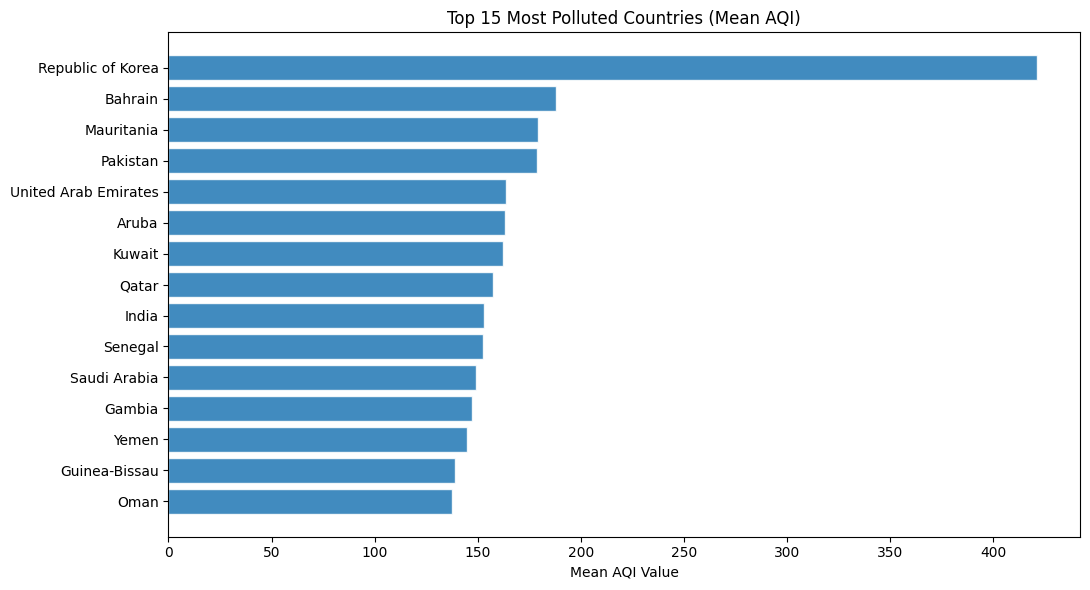

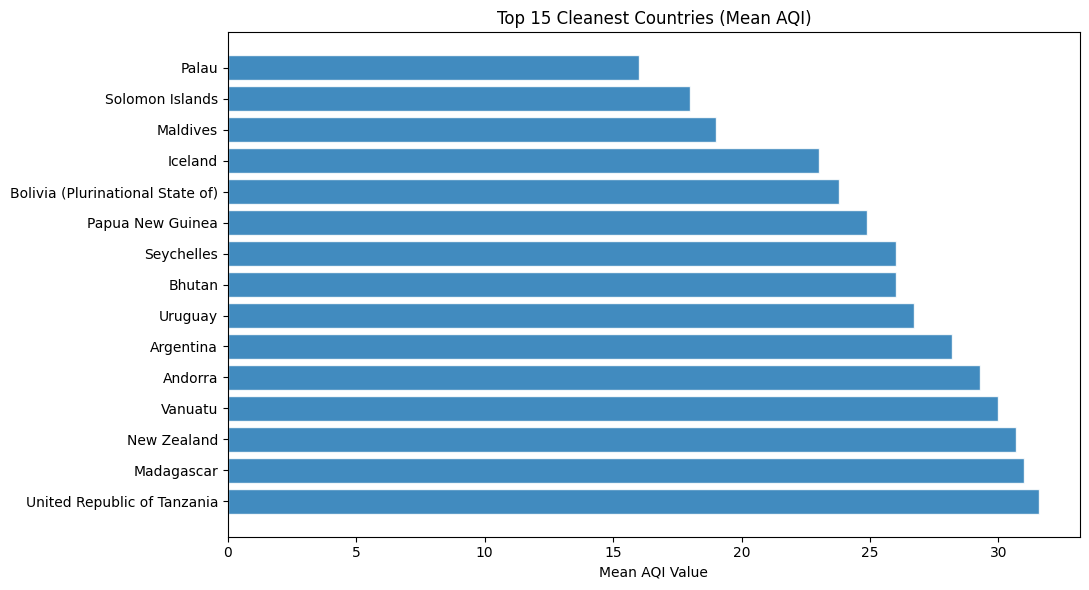

In [22]:
country_aqi = (
    df.groupby('Country')['AQI Value']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .round(1)
)

country_clean = (
    df.groupby('Country')['AQI Value']
    .mean()
    .sort_values(ascending=True)
    .head(15)
    .round(1)
)

plt.figure(figsize=(11, 6))
bars = plt.barh(country_aqi.index[::-1], country_aqi.values[::-1], edgecolor='white', alpha=0.85)
plt.xlabel('Mean AQI Value')
plt.title('Top 15 Most Polluted Countries (Mean AQI)')
plt.tight_layout()
plt.show()


plt.figure(figsize=(11, 6))
bars = plt.barh(country_clean.index[::-1], country_clean.values[::-1], edgecolor='white', alpha=0.85)
plt.xlabel('Mean AQI Value')
plt.title('Top 15 Cleanest Countries (Mean AQI)')
plt.tight_layout()
plt.show()

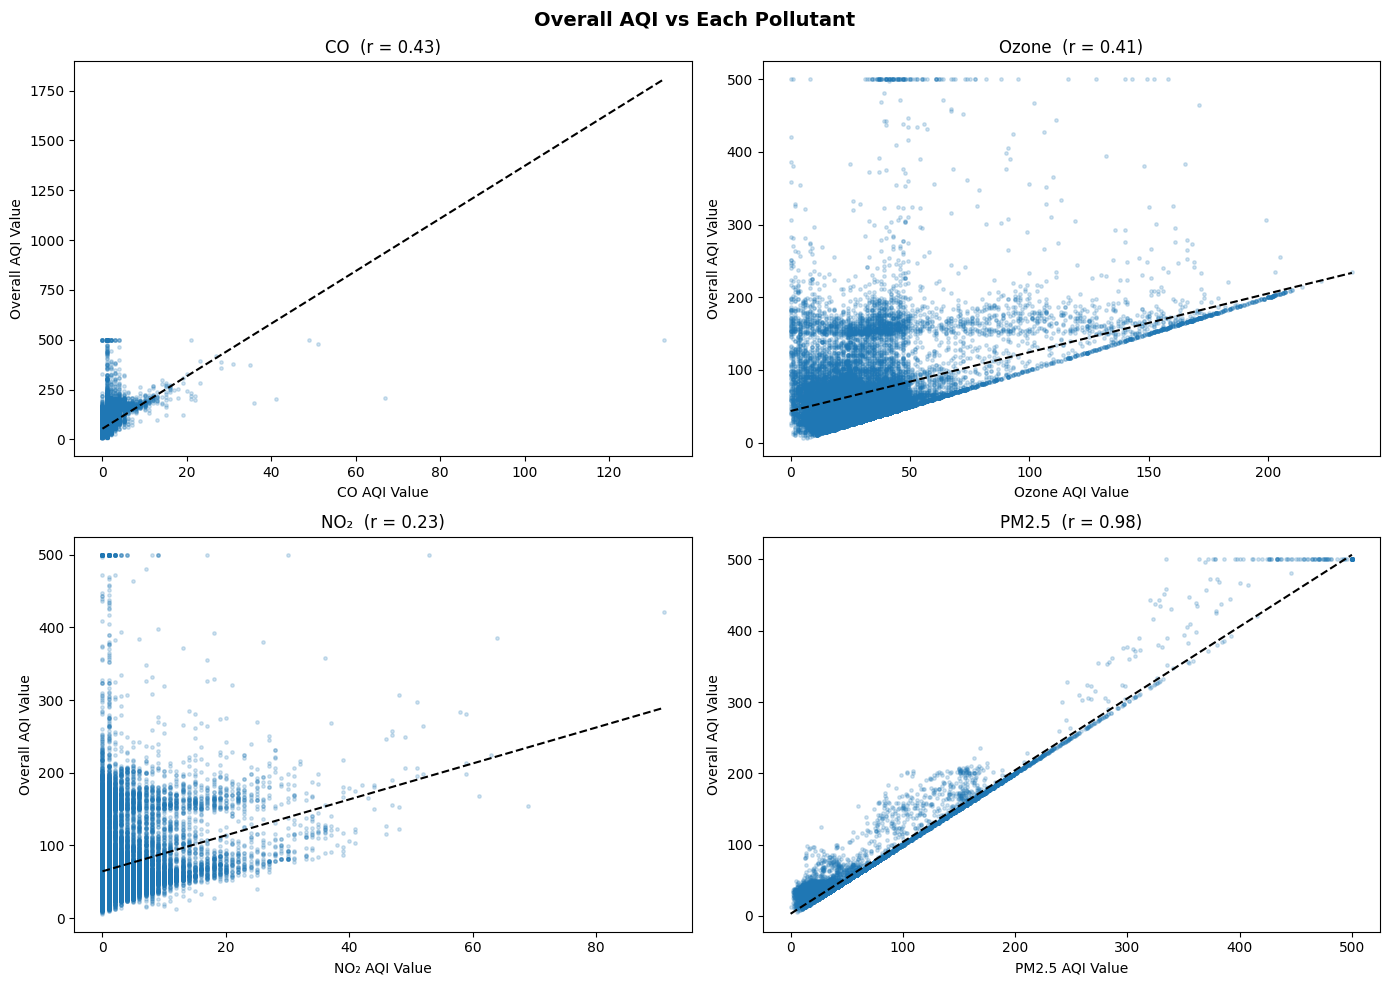

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Overall AQI vs Each Pollutant', fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, col, label, in zip(axes, pollutants, poll_labels,):
    clean = df[[col, 'AQI Value']].dropna()

    ax.scatter(clean[col], clean['AQI Value'],
               alpha=0.2, s=6)

    z = np.polyfit(clean[col], clean['AQI Value'], 1)
    p = np.poly1d(z)
    xs = np.linspace(clean[col].min(), clean[col].max(), 200)
    ax.plot(xs, p(xs), color='black', linewidth=1.5, linestyle='--')

    r = clean[col].corr(clean['AQI Value'])
    ax.set_title(f'{label}  (r = {r:.2f})')
    ax.set_xlabel(f'{label} AQI Value')
    ax.set_ylabel('Overall AQI Value')

plt.tight_layout()
plt.show()